# [Phystech@DataScience](https://thetahat.ru/courses/ph-ds-group)

## Домашнее задание 4 <font color="green">Профиль биология</font>

**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>

**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):
* Задача 1 &mdash; 25 баллов;
* Задача 2 &mdash; 100 баллов;


<b><font color="orange">Сложная часть</font></b> (необходимо на "отл"):
* Задача 3 &mdash; 30 баллов

In [ ]:
# Bot check

# HW_ID: phds_hw4
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

# Profile: Biology

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

from tqdm.notebook import tqdm
from typing import Tuple, List, Dict, Any, Optional

import seaborn as sns
sns.set_theme('notebook', font_scale=1.2, palette='Set2')

### Ссылки на чат с ИИ

Если при решении задач использовался ИИ, укажите здесь ссылки.

**Задача 1**
1. ...
2. ...

**Задача 2**
1. ...
2. ...

**Задача 3**
1. ...
2. ...


---
### Задача 1.

Исследуем Elastic-регрессию.

**1.** Визуализируйте множество, которое ограничивает коэффициенты в Elastic-регрессии.

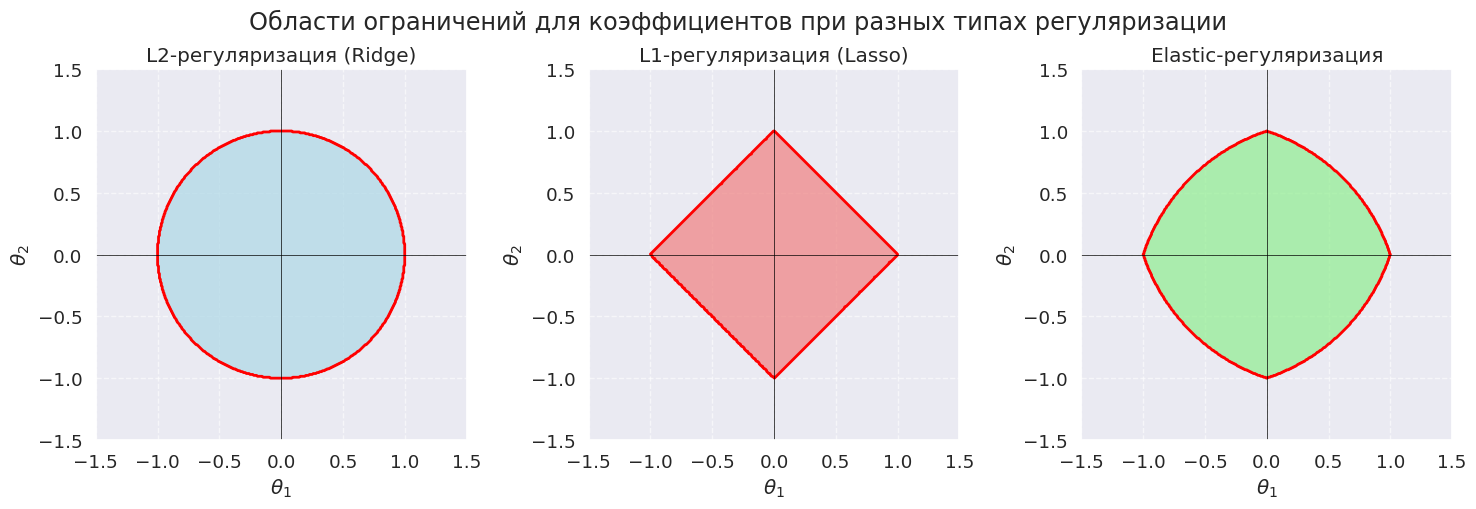

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Создаем сетку значений для коэффициентов theta1 и theta2
theta1 = np.linspace(-1.5, 1.5, 400)
theta2 = np.linspace(-1.5, 1.5, 400)
T1, T2 = np.meshgrid(theta1, theta2)

# 1. Ограничение для L2-регуляризации (Ridge): t1^2 + t2^2 <= 1 (круг радиуса 1)
l2_constraint = T1**2 + T2**2 <= 1

# 2. Ограничение для L1-регуляризации (Lasso): |t1| + |t2| <= 1 (ромб)
l1_constraint = np.abs(T1) + np.abs(T2) <= 1

# 3. Ограничение для Elastic-регуляризации (смесь L1 и L2)
#    Например: 0.5*(|t1|+|t2|) + 0.5*(t1^2+t2^2) <= 1
#    Коэффициенты 0.5 и 0.5 показывают смесь. Изменяя их, мы можем получать разные формы.
alpha = 0.5 # Коэффициент для L1 части
elastic_constraint = alpha * (np.abs(T1) + np.abs(T2)) + (1-alpha) * (T1**2 + T2**2) <= 1

# Создаем фигуру с тремя подграфиками
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Цвета для областей
colors = ['lightblue', 'lightcoral', 'lightgreen']
titles = ['L2-регуляризация (Ridge)', 'L1-регуляризация (Lasso)', 'Elastic-регуляризация']
constraints = [l2_constraint, l1_constraint, elastic_constraint]

for i, ax in enumerate(axes.flat):
    # Рисуем область допустимых значений
    ax.contourf(T1, T2, constraints[i], levels=[0.5, 1], colors=colors[i], alpha=0.7)
    # Рисуем границу области
    ax.contour(T1, T2, constraints[i], levels=[0.5], colors='red', linewidths=2)
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_title(titles[i])
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.suptitle('Области ограничений для коэффициентов при разных типах регуляризации')
plt.tight_layout()
plt.show()

**2.** Выпишите формулы для градиентного и стохастического спуска.

## Градиентный спуск
$$\theta_{t+1} = \theta_t - \eta x^T (x \theta_t - y)$$

## Стохастический градиентный спуск
$$\theta_{t+1} = \theta_t - \eta x_j^T (x_j \theta_t - y_j)$$

---
### Задача 2.


#### Введение


**РНК-интерференция** (англ. RNA interference; RNAi) &mdash; это естественный биологический процесс и перспективный с медицинской точки зрения метод подавления экспрессии генов в эукариотических клетках. Его применяют для изучения функций генов, [разработки новых лекарств](https://www.biopreparations.ru/jour/article/view/575?utm_source=chatgpt.com), а также при генной терапии.

Механизм РНК-интерференции работает так: поступившая в клетку экзогенная двухцепочечная РНК связывается с <abbr title="Рибонуклеазы (или РНК-азы) - ферменты-нуклеазы, катализирующие  расщепление РНК на более мелкие компоненты. Dicer относится к семеству РНКазы III.">рибонуклеазой Dicer</abbr>, которая нарезает ее на  ***малые интерферирующие РНК,*** **или миРНК**  **(small interfering RNA, siRNA)** &mdash; *небольшие фрагменты длиной 20–25 пар нуклеотидов*. Эти фрагменты взаимодействуют с <abbr title="RNA-induced silencing complex или RISC — мультибелковый комплекс, в состав которого входит один из белков семейства Argonaute и малые интерферирующие РНК. Белки Argonaute имеют эндонуклеазную активность по отношению к мРНК, комплементарным связанному фрагменту миРНК.">комплексом RISC</abbr>, который использует siRNA как «наводку» для поиска нужной молекулы мРНК и расщепляет её, подавляя работу гена.

> 📌 *Примечание.* В русскоязычной литературе аббревиатурой "миРНК" обозначают как siRNA, так и <abbr title="МикроРНК (miRNA) — это короткие эндогенные РНК, которые, подобно siRNA, подавляют экспрессию генов, но связываются они с мРНК частично комплементарно, регулируя множество мишеней и подавляя трансляцию, а не вызывая прямую деградацию.">miRNA (микро-РНК)</abbr>, что нередко приводит к путанице. Условимся, под миРНК мы будем иметь в виду именно *малые интерферирующие РНК (siRNA)*.


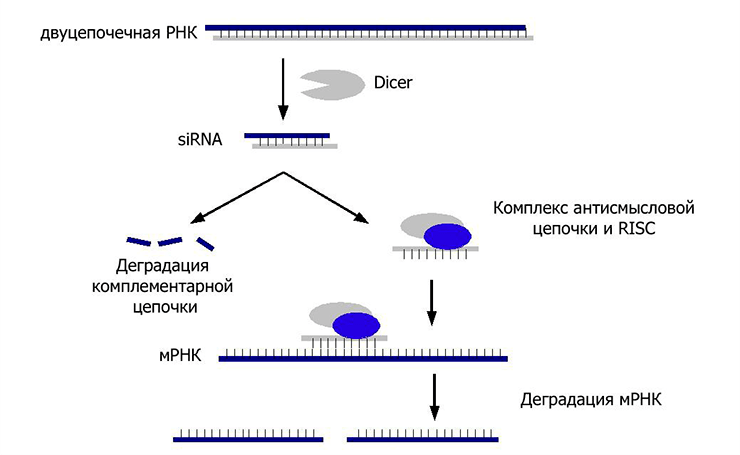



**Проблема**

Не все миРНК одинаково эффективны в подавлении экспрессии генов. Способность миРНК к ингибированию измеряется с помощью количественной <abbr title="ПЦР с обратной транскрипцией">ОТ-ПЦР</abbr>, *однако* существуют гипотезы, что определенные характеристики олигонуклеотидов могут предсказать их эффективность.

**Описание датасета**

[Датасет](https://www.kaggle.com/datasets/livtoft/sirna-activity/data) содержит 653 олигонуклеотида, информацию о целевой мРНК, последовательности миРНК, а также характеристики, которые могут быть предикторами активности миРНК.

* `target mRNA` &mdash; идентификатор целевой мРНК.

* `Start / End` &mdash; начальная и конечная позиции миРНК на целевой мРНК.

* `Sequence` &mdash; последовательность нуклеотидов в миРНК.

* `G / U` &mdash; количество нуклеотидов гуанина (G) и урацила (U) в миРНК.

* `bi` &mdash; стабильность димеров антисмысловой цепи (энергия связи между одинаковыми цепями).

* `uni` &mdash; внутримолекулярная стабильность антисмысловой цепи (способность цепи формировать петли или шпильки).

* `duplex` &mdash; энергия связи между антисмысловой и смысловой цепями миРНК (чем меньше, тем прочнее комплекс).

* `Pos1,2,6,13,14,18` &mdash; стабильность связи пар оснований в ключевых позициях siRNA при взаимодействии с мРНК.
* `Dif_5-3` &mdash; разница стабильности концов миРНК (5' и 3').

* `Content+ / Content-` &mdash; содержание нуклеотидов на положительной и отрицательной цепи.

* `Cons+ / Cons- / Cons_Sum` &mdash; консервативность последовательностей (на положительной, отрицательной цепи и суммарно).

* `Hyb19` &mdash; энергия гибридизации с мРНК (длина 19 пар оснований).

* `target` &mdash; цель (идентификатор).

* `Activity` &mdash; процент остаточной экспрессии целевой мРНК. **Чем меньше активность, тем выше эффективность подавления экспрессии гена.**

Согласно [оригинальной статье](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-7-65#Tab1), эти признаки должны помочь выявлять миРНК, наиболее эффективно подавляющие экспрессию гена.

**1.** **Загрузка и подготовка данных**

Загрузите датасет и выведите его размер и первые несколько строк.

In [8]:
data = pd.read_csv('data.csv')
print('Размер датасета:', data.shape)
print('\Первые 5 строк:')
data.head()

Размер датасета: (653, 24)
\Первые 5 строк:


,Target seq,Start,End,Sequence,G,U,bi,uni,duplex,Pos1,...,Pos18,Dif_5-3,Content+,Content-,Cons+,Cons-,Cons_Sum,Hyb19,target,Activity
0,M60857,195,213,AUUAUCCACUGUUUUUGGA,3,9,-7.0,-1.9,-28.1,-1.1,...,-2.4,-1.3,2,6,2,6,4,0.001175,-8.1,24.7
1,M60857,197,215,AAAUUAUCCACUGUUUUUG,2,9,-0.7,0.0,-24.2,-0.9,...,-2.1,-1.2,1,6,1,5,4,0.001175,-8.1,9.8
2,M60857,199,217,CAAAAUUAUCCACUGUUUU,1,8,-1.5,0.0,-24.2,-2.1,...,-0.9,1.2,2,5,3,2,-1,0.001175,-11.4,50.5
3,M60857,201,219,CACAAAAUUAUCCACUGUU,1,6,-0.6,0.0,-26.7,-2.1,...,-0.9,1.2,3,3,3,3,0,0.001175,-14.5,83.7
4,M60857,203,221,GCCACAAAAUUAUCCACUG,2,4,-0.1,0.0,-30.3,-3.4,...,-2.1,1.3,4,2,2,3,1,0.001175,-17.8,60.3


Проверьте, есть ли в данных пропуски? Все ли столбцы имеют числовой формат?

In [9]:
print('Пропуски:', data.isnull().sum().sum())
print('Числовые столбцы:', list(data.select_dtypes(include=['number']).columns))

Пропуски: 0
Числовые столбцы: ['Start', 'End', 'G', 'U', 'bi', 'uni', 'duplex', 'Pos1', 'Pos2', 'Pos6', 'Pos13', 'Pos14', 'Pos18', 'Dif_5-3', 'Content+', 'Content-', 'Cons+', 'Cons-', 'Cons_Sum', 'Hyb19', 'target', 'Activity']


**Ответ:**
пропусков нет, есть не числовые данные

Отличается ли масштаб у числовых признаков?

In [10]:
numeric_cols = data.select_dtypes(include=['number']).columns
print(data[numeric_cols].describe().round(2))

         Start      End       G       U      bi     uni  duplex    Pos1  \
count   653.00   653.00  653.00  653.00  653.00  653.00  653.00  653.00   
mean    972.72   990.72    4.36    5.42   -7.45   -1.11  -34.11   -2.06   
std     769.98   769.98    1.98    2.33    4.68    1.49    4.37    0.76   
min       1.00    19.00    0.00    0.00  -26.60   -7.90  -49.90   -3.40   
25%     329.00   347.00    3.00    4.00   -9.90   -1.90  -36.70   -2.40   
50%     779.00   797.00    4.00    5.00   -7.00   -0.30  -33.70   -2.10   
75%    1504.00  1522.00    6.00    7.00   -4.00    0.00  -31.00   -1.30   
max    5524.00  5542.00   12.00   13.00    4.10    0.00  -22.30   -0.90   

         Pos2    Pos6  ...   Pos18  Dif_5-3  Content+  Content-   Cons+  \
count  653.00  653.00  ...  653.00   653.00    653.00    653.00  653.00   
mean    -2.09   -2.15  ...   -2.17    -0.11      3.27      3.17    3.87   
std      0.77    0.76  ...    0.77     1.04      1.85      2.09    1.66   
min     -3.40   -3.40  .

**Ответ:**
значения отличаются, значит будет необхожима стандартизация

Посмотрим на распределение активности:

<Axes: xlabel='Activity', ylabel='Count'>

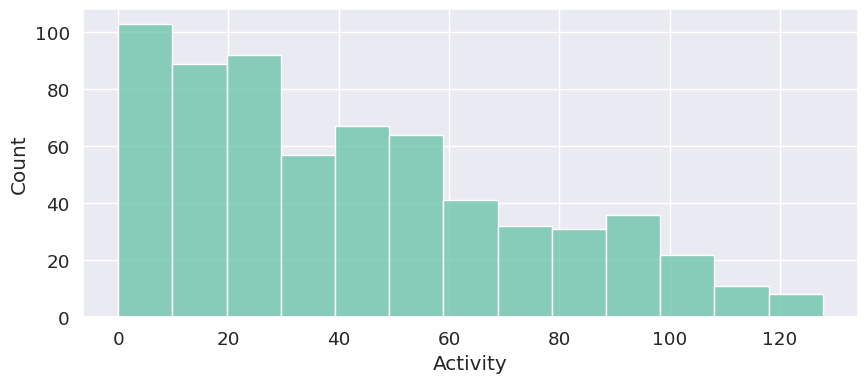

In [11]:
plt.figure(figsize=(10, 4))
sns.histplot(data["Activity"])

Удивление могут вызывать значения активности свыше 100%. Как будто бы в некоторых случаях последовательность миРНК вместо подавления, напротив, усиливала экспрессию мРНК. Эта тайна, покрытая мраком, остаётся на совести экспериментаторов 🤔. Более важно научиться предсказывать эффективные последовательности, при применении которых остаточная активность мала. В качестве порогового значения возьмём 30% и будем пытаться отделять (классифицировать) эффективные и неэффективные цепочки миРНК по такому правилу:

*   1 (эффективная): миРНК снижает уровень мРНК более чем на 70% (значение активности ≤ 30%).

*   0 (неэффективная): миРНК снижает уровень мРНК менее чем на 70% (значение активности > 30%).

Установите порог, выделите матрицу признаков и целевую переменную:

In [13]:
# Устанавливаем порог и создаем целевую переменную
threshold = 30
y = (data['Activity'] <= threshold).astype(int)

# Выделяем числовые признаки (исключаем нечисловые и Activity)
X = data.select_dtypes(include=['number']).drop('Activity', axis=1)

print('Размер X:', X.shape)
print('Размер y:', y.shape)

Размер X: (653, 21)
Размер y: (653,)


Посчитайте количество нулей и единиц таргете (не путать с признаком `target`). Лучше всего представить ответ в виде графика с двумя столбцами, высота которых соответствует количеству объектов класса (см. например, [`sns.countplot`](https://seaborn.pydata.org/generated/seaborn.countplot.html)). Есть ли дисбаланс между классами?

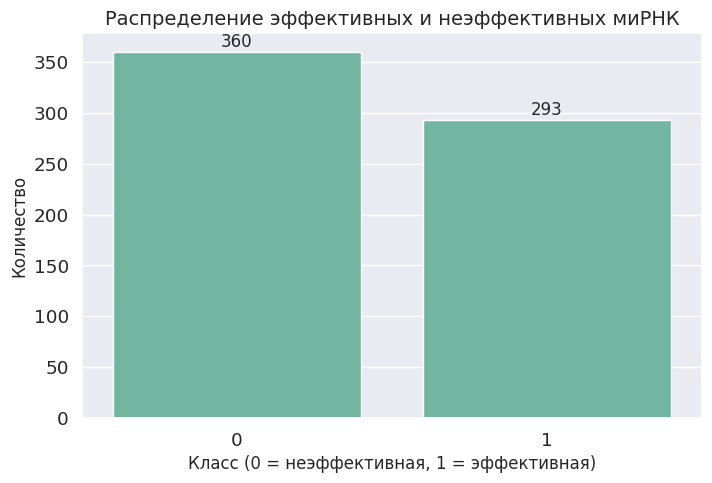

Количество (0): 360


In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title('Распределение эффективных и неэффективных миРНК', fontsize=14)
plt.xlabel('Класс (0 = неэффективная, 1 = эффективная)', fontsize=12)
plt.ylabel('Количество', fontsize=12)

# Добавляем подписи с количествами
for i, count in enumerate(y.value_counts().sort_index()):
    plt.text(i, count + 5, str(count), ha='center', fontsize=12)

plt.show()

# Выводим точные значения
print(f"Количество (0): {(y == 0).sum()}")

**Ответ:**
дисбаланс между классами есть, 0 больше чем 1

Разделите данные на обучающую и тестовую выборки в отношении 3:2. Вам не подойдет стандартный метод `test_train_split`, так как в данных есть группы (столбец `Target seq`): для каждой целевой последовательности подбирались различные цепочки миРНК:

Text(0.5, 1.0, 'Количество записей в данных по всем последовательностям (группам)')

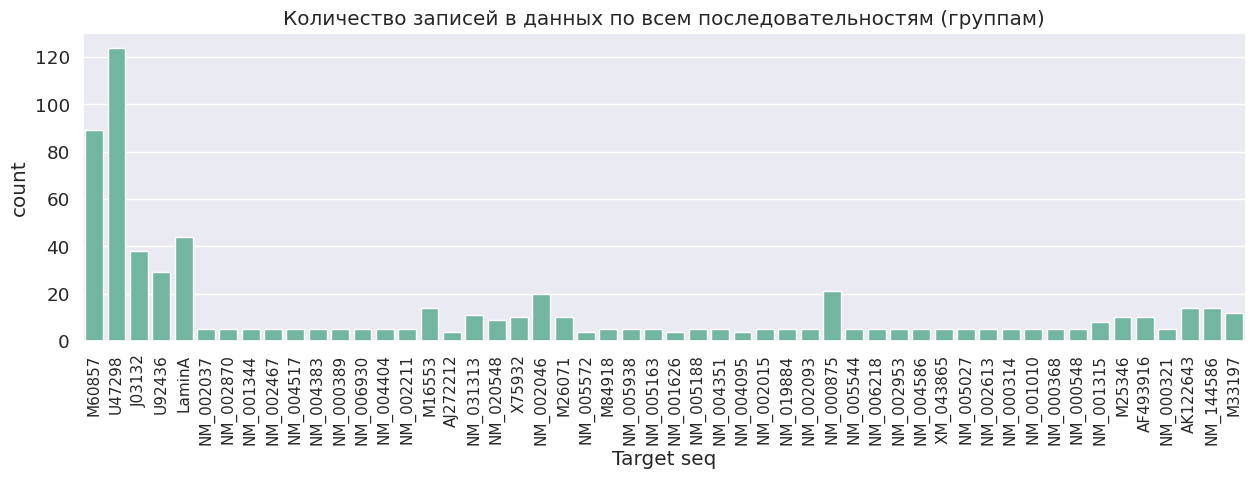

In [16]:
groups = data["Target seq"]

plt.figure(figsize=(15, 4))
sns.countplot(x=groups)
plt.xticks(rotation=90, fontsize=11)
plt.title("Количество записей в данных по всем последовательностям (группам)")

Реализуйте функцию для разделения выборки на трейн и тест так, чтобы каждая отдельная группа целиком попала либо в обучающую, либо в тестовую часть. Вы можете реализовать алгоритм самостоятельно или воспользоваться готовыми решениями, например [`GroupShuffleSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html), используя метод `groups`.

In [20]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Уникальных групп в train/test: {len(set(groups.iloc[train_idx]))}/{len(set(groups.iloc[test_idx]))}")

Train: (417, 21), Test: (236, 21)
Уникальных групп в train/test: 31/21


Выведите что-либо, подтверждающее корректность вашего разбиения.

Чем плоха ситуация, в которой элементы выборки, соответствующие одной и той же целевой последовательности, раздятся и попадут одновременно в тестовую и обучающую части?

In [21]:
# Проверка 1: пересечение групп
groups_train = set(groups.iloc[train_idx])
groups_test = set(groups.iloc[test_idx])
intersection = groups_train & groups_test
print(f"Пересечение групп между train и test: {intersection}")
print(f"Есть пересечение? {len(intersection) > 0}")

# Проверка 2: случайная группа и её распределение
sample_group = list(groups_train)[0]
print(f"\nПример группы из train: {sample_group}")
print(f"Все индексы для этой группы: {list(groups[groups == sample_group].index)}")
print(f"Из них в train: {[i for i in groups[groups == sample_group].index if i in train_idx]}")
print(f"Из них в test: {[i for i in groups[groups == sample_group].index if i in test_idx]}")

# Проверка 3: статистика по группам
print(f"\nВсего уникальных групп: {len(groups.unique())}")
print(f"Групп в train: {len(groups_train)}")
print(f"Групп в test: {len(groups_test)}")
print(f"Сумма: {len(groups_train) + len(groups_test)} = {len(groups.unique())}")

Пересечение групп между train и test: set()
Есть пересечение? False

Пример группы из train: NM_000548
Все индексы для этой группы: [519, 520, 521, 522, 523]
Из них в train: [519, 520, 521, 522, 523]
Из них в test: []

Всего уникальных групп: 52
Групп в train: 31
Групп в test: 21
Сумма: 52 = 52


Модель обучится на тестовых данных и потом выдаст лучшие результаты, чем есть на самом деле

Аналогичным образом, выведите распределение таргета по классам для обеих выборок. Одинаково ли соотношение классов в обучающей и тестовой частях?

In [23]:
# Распределение классов в обучающей выборке
train_class_dist = y_train.value_counts().sort_index()
print("Обучающая выборка:")
print(f"Класс 0 : {train_class_dist[0]} ({train_class_dist[0]/len(y_train)*100:.1f}%)")
print(f"Класс 1 : {train_class_dist[1]} ({train_class_dist[1]/len(y_train)*100:.1f}%)")

# Распределение классов в тестовой выборке
test_class_dist = y_test.value_counts().sort_index()
print("тестовая выборка:")
print(f"Класс 0 : {test_class_dist[0]} ({test_class_dist[0]/len(y_test)*100:.1f}%)")
print(f"Класс 1 : {test_class_dist[1]} ({test_class_dist[1]/len(y_test)*100:.1f}%)")


Обучающая выборка:
Класс 0 : 227 (54.4%)
Класс 1 : 190 (45.6%)
тестовая выборка:
Класс 0 : 133 (56.4%)
Класс 1 : 103 (43.6%)


**Ответ:**
Соотношения похожи, но не совсем одинаковы, это нормально, тк GroupShuffleSplit сохраняет целостность групп, но не стратифицирует по целевой переменной

Далее, при построении классификатора, учитывайте диcбаланс, если он есть: используйте взвешенную версию логистической регрессии (см. параметр `class_weight`) и метрику [`balanced_accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html#sklearn.metrics.balanced_accuracy_score) для оценки качества модели. Если дисбаланс незначителен, можно использовать невзвешенные версии.

Стандартизируйте данные.

In [24]:
# Стандартизация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Проверка результатов
print(f"Средние после стандартизации (train): {X_train_scaled.mean(axis=0).round(2)}")
print(f"Стандартные отклонения после стандартизации (train): {X_train_scaled.std(axis=0).round(2)}")

Средние после стандартизации (train): [ 0.  0.  0. -0.  0.  0. -0.  0.  0. -0. -0. -0.  0. -0. -0. -0. -0. -0.
 -0. -0.  0.]
Стандартные отклонения после стандартизации (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Хорошо ли обусловлена матрица $X$? О чём это говорит?

In [ ]:
<...>

**Ответ:**
Да, хорошо. Стандартизация привела все признаки к нулевому среднему и единичному стандартному отклонению. Это говорит о том, что модель будет обучаться правильно, градиентный спуск будет сходиться более стабильно.

Для наглядности, выведите матрицу корреляций. Что означают элементы матрицы? А в нашем случае?

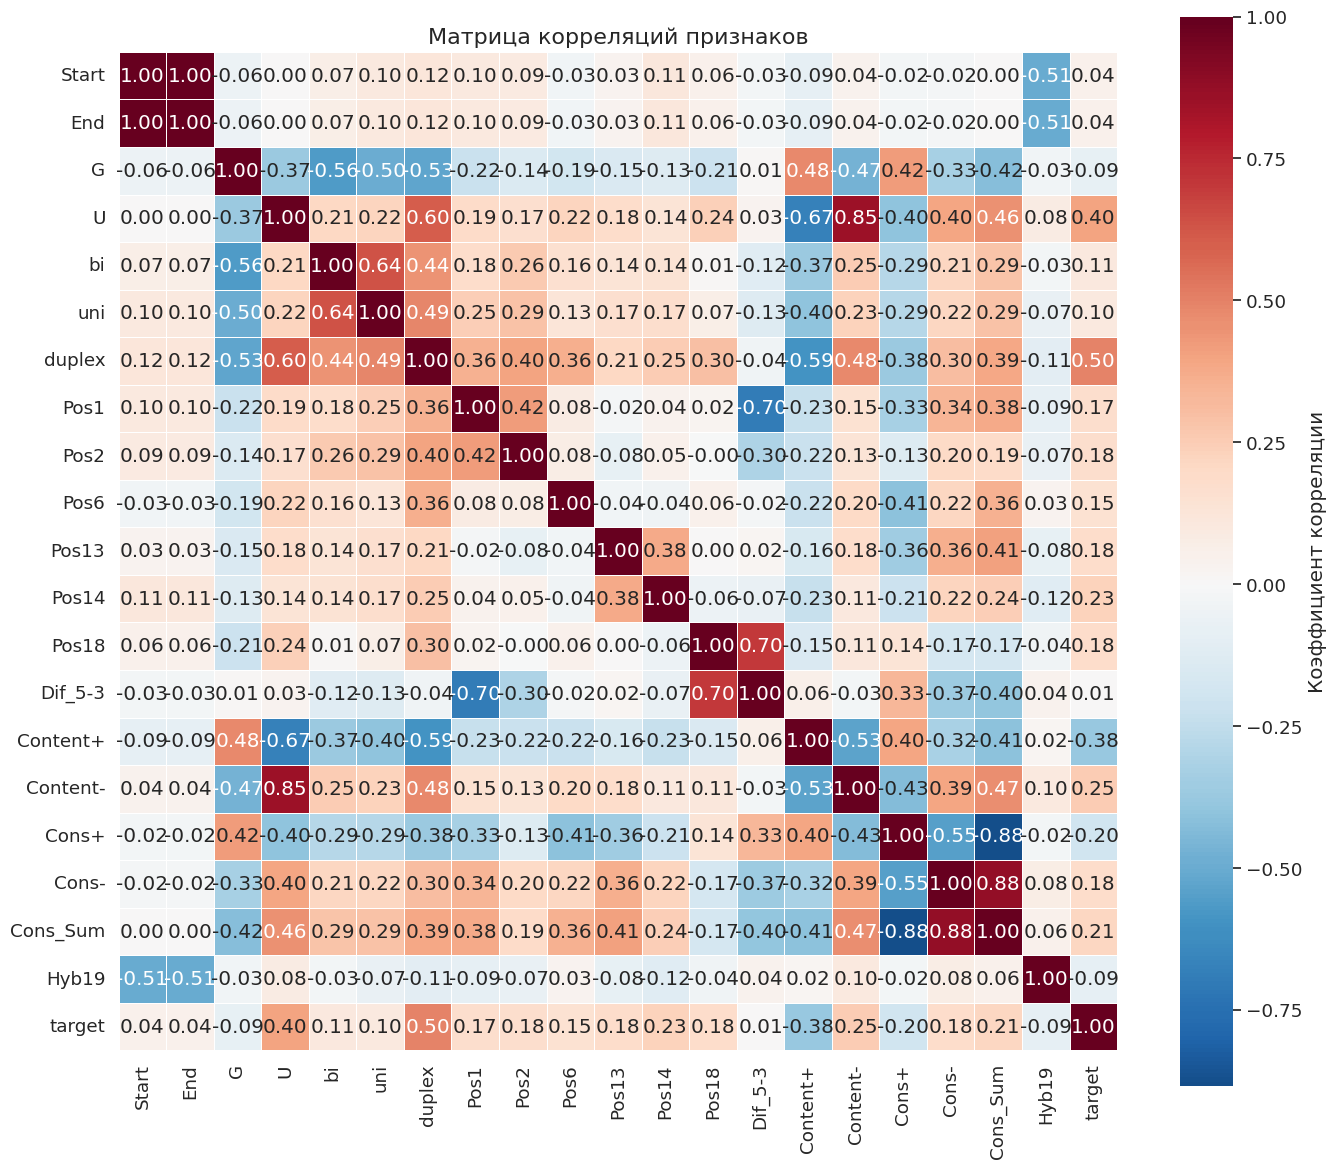

Диапазон корреляций: [-0.88, 1.00]
Средняя корреляция: 0.22
Доля сильных корреляций (|r| > 0.5): 7.6%


In [26]:
# Матрица корреляций
corr_matrix = X_train.corr()

# Визуализация
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

# Статистика по корреляциям
# Убираем диагональ (корреляция признака с самим собой = 1)
corr_values = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
print(f"Диапазон корреляций: [{corr_values.min():.2f}, {corr_values.max():.2f}]")
print(f"Средняя корреляция: {np.mean(np.abs(corr_values)):.2f}")
print(f"Доля сильных корреляций (|r| > 0.5): {(np.abs(corr_values) > 0.5).mean()*100:.1f}%")

**Ответ:**
Есть мультиколлинеарность, некоторые признаки сильно коррелируют.Логистическая регрессия без регуляризации может быть нестабильна.

  



Делать предобработку вручную не вполне удобно и правильно. Гораздо лучше использовать пайплайн. Для этого зададим порядок выполнения преобразований так, как этого требует объект типа [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html). В нашем случае это единственное преобразование:

In [27]:
preproc_steps = [('scaler', StandardScaler())]
pipeline = Pipeline(preproc_steps)

Теперь для создания пайплайна достаточно добавить саму модель как четвёртый шаг:

In [28]:
model = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('estimator', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]
)

# Обучение одной командой
model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_test)

# Оценка
from sklearn.metrics import accuracy_score, balanced_accuracy_score
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")

Accuracy: 0.648
Balanced Accuracy: 0.634


Такой подход является более надёжным и удобным.

**2.** **Модельки, модельки, модельки...**

**2.1** **Самый популярный класс**

Найдите самый популярный класс в обучающей выборке и посчитайте точность ответа на трейне и тесте только этим классом &mdash; константой. Отличается ли взвешенная точность от обычной?

In [30]:
most_frequent_class = y_train.mode()[0]
print(f"Самый популярный класс в train: {most_frequent_class}")

# Константные предсказания
y_pred_const_train = np.full_like(y_train, most_frequent_class)
y_pred_const_test = np.full_like(y_test, most_frequent_class)

# accuracy
acc_train = accuracy_score(y_train, y_pred_const_train)
acc_test = accuracy_score(y_test, y_pred_const_test)

# balanced accuracy
bal_acc_train = balanced_accuracy_score(y_train, y_pred_const_train)
bal_acc_test = balanced_accuracy_score(y_test, y_pred_const_test)

print(f"\nTrain: accuracy = {acc_train:.3f}, balanced accuracy = {bal_acc_train:.3f}")
print(f"Test:  accuracy = {acc_test:.3f}, balanced accuracy = {bal_acc_test:.3f}")

Самый популярный класс в train: 0

Train: accuracy = 0.544, balanced accuracy = 0.500
Test:  accuracy = 0.564, balanced accuracy = 0.500


**Вывод:**
Дисбаланс незначительный, класс 0 составляет ~54-56%, класс 1 ~44-46%. Обычная accuracy обманчива 56% выглядит неплохо, но это просто угадывание самого частого класса. Любая разумная модель должна давать balanced accuracy > 0.5 — иначе она не лучше случайного угадывания



**2.2** **Логистическая регрессия без регуляризации**

Обучите классическую логистическую регрессию и выведите точность ответа на трейне и тесте. Используйте взвешенный вариант, если в данных есть заметный дисбаланс

><details>
>  <summary>  Подсказка ✍️</summary>
>  Чему равен аргумент <code>penalty</code> по умолчанию?
</details><br/>

In [31]:
# Проверяем дисбаланс (по предыдущим результатам он небольшой)
class_weights = None  # или 'balanced' при сильном дисбалансе

# Модель без регуляризации
model_no_reg = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('estimator', LogisticRegression(penalty=None, class_weight=class_weights, max_iter=1000, random_state=42))
])

# Обучение
model_no_reg.fit(X_train, y_train)

# Предсказания
y_train_pred = model_no_reg.predict(X_train)
y_test_pred = model_no_reg.predict(X_test)

# Оценка
print(f"Train accuracy: {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Train balanced accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")
print(f"Test balanced accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ БЕЗ РЕГУЛЯРИЗАЦИИ
Train accuracy: 0.753
Test accuracy: 0.619
Train balanced accuracy: 0.750
Test balanced accuracy: 0.597


**Вывод:**
Сильное переобучение разрыв между train и test небольшой. Без регуляризации модель подстроилась под шум, тк веса стали слишком большими и специфичными для train. Нужна регуляризация — чтобы уменьшить переобучение и улучшить обобщающую способность

**2.3** **Логистическая регрессия с регуляризацией**

За что отвечает гиперпараметр `C` у класса `LogisticRegression` и чему он равен?

**Ответ:**
Чем меньше С, тем сильнее регуляризация, С = 1/гамму, где гамма -- коэффициент регуляризации

Вам необходимо исследовать зависимость от `C` следующих величин:
1. Accuracy на трейне
2. Accuracy на тесте
3. Коэффициенты модели

Чтобы не приходилось постоянно обучать модели при одних и тех же сетках `C`, предлагается написать функцию, которая будет принимать на вход вид штрафа `penalty`, границы диапазона `C`, и саму выборку. На каждой итерации вычисляйте все величины и сохраняйте в виде списков. Для мониторинга времени работы используйте функцию `tqdm`.

Не забудьте также про дисбаланс классов, если он имеется.

In [ ]:
def train_alpha_grid(
    log_C_bounds: Tuple[float, float],
    resolution: int,
    data: Dict[str, Any],
    preproc_steps: List[Tuple[str, Any]],
    penalty: str = 'none',
    solver: str = 'newton-cholesky',
    max_iter: int = 100,
) -> Tuple[List[np.ndarray], List[float], List[float]]:
    """Обучает модель LogisticRegression для разных значений параметра регуляризации C,
    сохраняет коэффициенты, вычисляет accuracy на обучающей и тестовой выборках.

    Args:
        log_C_bounds (Tuple[float, float]): кортеж с минимальным и максимальным значением log10(C) для сетки.
        resolution (int): число точек на сетке `C`.
        data (dict): словарь с обучающей и тестовой выборками (например, {'X_train': ..., 'y_train': ..., 'X_test': ..., 'y_test': ...}).
        preproc_steps (List[Tuple[str, Any]]): список шагов пайплайна.
        penalty (str): тип регуляризации ('l1', 'l2', 'elasticnet', 'none').
        solver (str): метод оптимизации параметров модели (см. аргумент `solver` у класса `LogisticRegression`).
        max_iter (int): обучение останавливается, если требуемая точность не достигнута за `max_iter` итераций.

    Returns:
        C_grid (np.ndarray): сетка значений `C`.
        coefs_list (List[np.ndarray]): список массивов коэффициентов для каждого значения `C`.
        acc_train_list (List[float]): список accuracy на обучающей выборке для каждого значения `C`.
        acc_test_list (List[float]): список accuracy на тестовой выборке для каждого значения `C`.
    """

    <...>

In [45]:
def train_alpha_grid(
    log_C_bounds: Tuple[float, float],
    resolution: int,
    data: Dict[str, Any],
    preproc_steps: List[Tuple[str, Any]],
    penalty: str = 'none',
    solver: str = 'newton-cholesky',
    max_iter: int = 100,
) -> Tuple[np.ndarray, List[np.ndarray], List[float], List[float]]:
    # Создаем сетку значений C в логарифмической шкале
    log_C_min, log_C_max = log_C_bounds
    C_grid = np.logspace(log_C_min, log_C_max, resolution)

    # Инициализируем списки для результатов
    coefs_list = []
    acc_train_list = []
    acc_test_list = []

    # Определяем class_weight на основе дисбаланса
    y_train = data['y_train']
    class_weights = 'balanced' if y_train.value_counts().min() / len(y_train) < 0.3 else None

    # Основной цикл по значениям C
    for C in tqdm(C_grid, desc=f'Обучение моделей (penalty={penalty})'):

        # Создаем пайплайн с текущим C
        if penalty == 'none':
            # Для penalty=None параметр C не используется
            model = Pipeline(steps=preproc_steps + [
                ('estimator', LogisticRegression(
                    penalty=None,
                    class_weight=class_weights,
                    solver=solver,
                    max_iter=max_iter,
                    random_state=42
                ))
            ])
        else:
            model = Pipeline(steps=preproc_steps + [
                ('estimator', LogisticRegression(
                    penalty=penalty,
                    C=C,
                    class_weight=class_weights,
                    solver=solver,
                    max_iter=max_iter,
                    random_state=42
                ))
            ])

        # Обучение
        model.fit(data['X_train'], data['y_train'])

        # Предсказания
        y_train_pred = model.predict(data['X_train'])
        y_test_pred = model.predict(data['X_test'])

        # Сохраняем результаты
        coefs_list.append(model.named_steps['estimator'].coef_.flatten())
        acc_train_list.append(accuracy_score(data['y_train'], y_train_pred))
        acc_test_list.append(accuracy_score(data['y_test'], y_test_pred))

    return C_grid, coefs_list, acc_train_list, acc_test_list

Проведите эксперимент для 3-х разных моделей логистической регрессии с различными типами регуляризации:
1.  $L_1$-регуляризация
2.  $L_2$-регуляризация
3.  Комбинированная регуляризация с параметром `l1_ratio=0.5`.

>*Рекомендации*
>*   Подберите диапазоны значений для гиперпараметра `C`. Не берите слишком узкие, чтобы видеть на графике всю картину. Для слишком широких границ придётся брать больше точек.
>*   Вам не нужна очень частая сетка гиперпараметра `C`. При отладке кода можно вообще использовать сетку из 2-3 значений.
>*   Вы можете столкнуться с различными ошибками и `warning`-ами (например, неверный `solver`, отсутствие сходимости,  и т. д.) Постарайтесь настроить гиперпараметры модели таким образом, чтобы ошибки исчезли, а количество предупреждений было минимальным.
>*  Для ускорения работы программы можно использовать параллельные вычисления, передав аргумент `n_jobs` в модель. Это особенно полезно при запуске на локальном компьютере, так как Google Colab предоставляет лишь два ядра ЦПУ по-умолчанию.
>*   Для начала полезно решить **п. 2.3** целиком и отладить код только для одного из типов регуляризации.

 L1 регуляризация 


Обучение моделей (penalty=l1):   0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


 L2 регуляризация 


Обучение моделей (penalty=l2):   0%|          | 0/30 [00:00<?, ?it/s]

 ELASTICNET регуляризация 


  0%|          | 0/30 [00:00<?, ?it/s]

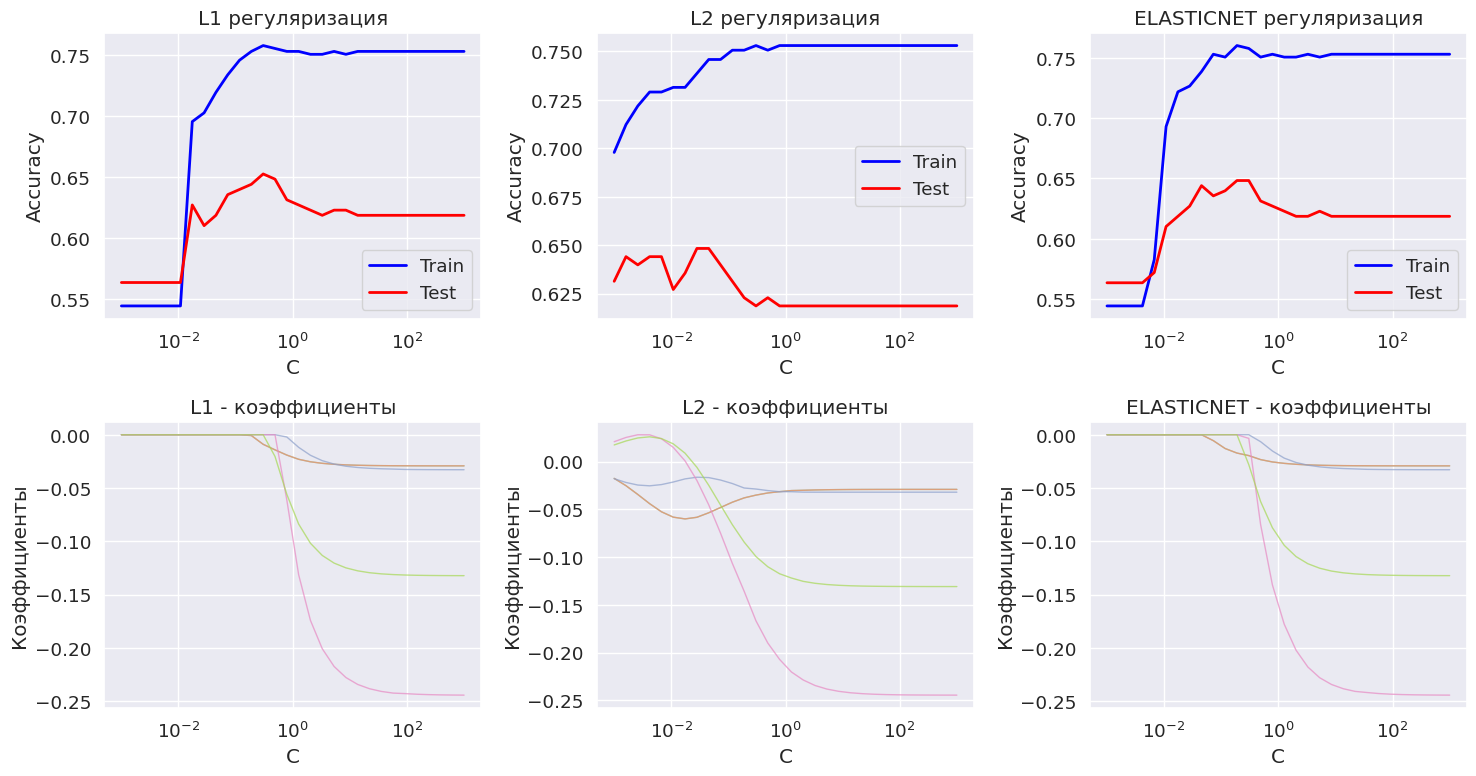

In [50]:
# Подготавливаем данные
model_data = {
    'X_train': X_train, 'y_train': y_train,
    'X_test': X_test, 'y_test': y_test
}

preproc_steps = [('scaler', StandardScaler())]

# Исследуем 3 типа регуляризации
penalties = ['l1', 'l2', 'elasticnet']
results = {}

for penalty in penalties:
    print(f" {penalty.upper()} регуляризация ")

    if penalty == 'elasticnet':
        # Для ElasticNet нужен специальный подход
        C_grid = np.logspace(-3, 3, 30)
        coefs_list, acc_train, acc_test = [], [], []

        for C in tqdm(C_grid):
            model = Pipeline(steps=preproc_steps + [
                ('estimator', LogisticRegression(
                    penalty='elasticnet',
                    l1_ratio=0.5,
                    C=C,
                    solver='saga',
                    max_iter=2000,  # увеличили для сходимости
                    random_state=42
                ))
            ])
            model.fit(X_train, y_train)
            coefs_list.append(model.named_steps['estimator'].coef_.flatten())
            acc_train.append(accuracy_score(y_train, model.predict(X_train)))
            acc_test.append(accuracy_score(y_test, model.predict(X_test)))
    else:
        # Для L1 и L2 используем функцию
        C_grid, coefs_list, acc_train, acc_test = train_alpha_grid(
            log_C_bounds=(-3, 3),
            resolution=30,
            data=model_data,
            preproc_steps=preproc_steps,
            penalty=penalty,
            solver='saga' if penalty == 'l1' else 'lbfgs',  # lbfgs лучше для L2
            max_iter=2000
        )

    results[penalty] = {
        'C_grid': C_grid,
        'coefs': coefs_list,
        'acc_train': acc_train,
        'acc_test': acc_test
    }

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, (penalty, res) in enumerate(results.items()):
    # Верхний ряд: графики accuracy
    ax = axes[0, idx]
    ax.semilogx(res['C_grid'], res['acc_train'], 'b-', label='Train', linewidth=2)
    ax.semilogx(res['C_grid'], res['acc_test'], 'r-', label='Test', linewidth=2)
    ax.set_xlabel('C')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{penalty.upper()} регуляризация')
    ax.legend()
    ax.grid(True)

    # Нижний ряд: графики коэффициентов
    ax = axes[1, idx]
    coefs_array = np.array(res['coefs'])
    for i in range(min(5, coefs_array.shape[1])):
        ax.semilogx(res['C_grid'], coefs_array[:, i], alpha=0.7, linewidth=1)
    ax.set_xlabel('C')
    ax.set_ylabel('Коэффициенты')
    ax.set_title(f'{penalty.upper()} - коэффициенты')
    ax.grid(True)

plt.tight_layout()
plt.show()

Нарисуйте треки соответствующих коэффициентов моделей в зависимости от `C`. Свободный коэффициент тоже стоит добавить на графики, если он у вас есть. Легенду можно сделать общую, если все графики помещаются на экране. Отразите в ней наименования признаков для соответствующих коэффициентов. Сделать красиво могут помочь заметки [отсюда](https://stackoverflow.com/questions/4700614/how-to-put-the-legend-outside-the-plot).

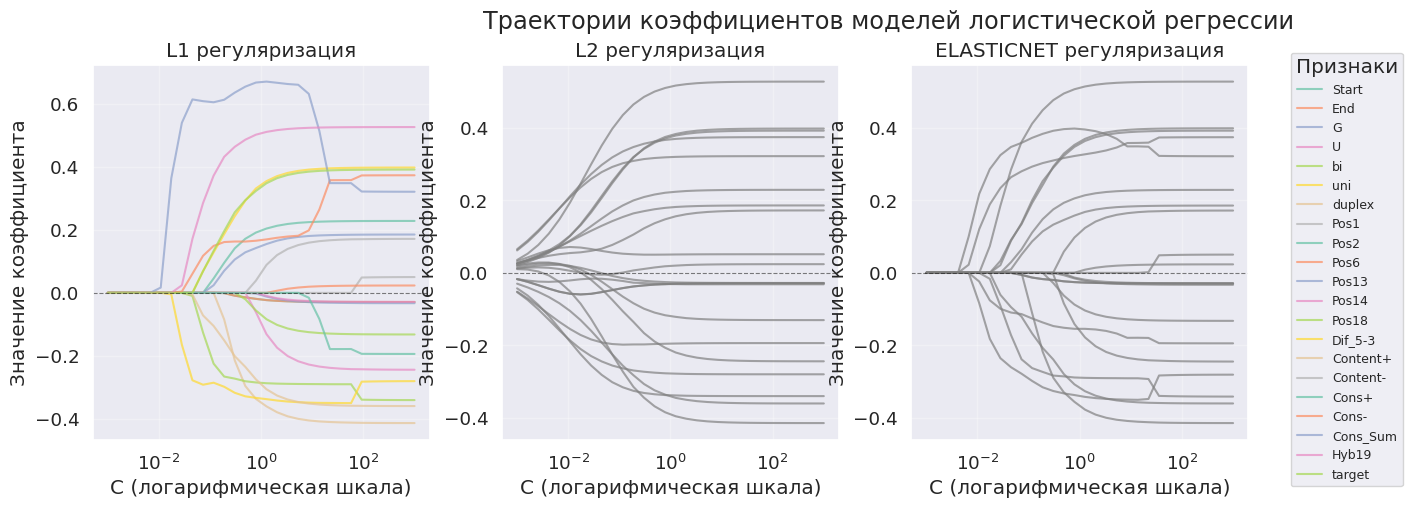

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lines_for_legend = {}
handles_for_legend = []

feature_names = X_train.columns.tolist()

for idx, (penalty, res) in enumerate(results.items()):
    ax = axes[idx]
    coefs_array = np.array(res['coefs'])  # Массив размером (n_C, n_features)

    # Рисуем траекторию для каждого коэффициента
    for i in range(coefs_array.shape[1]):
        # Для первой модели (L1) запоминаем линии, чтобы сделать общую легенду
        if idx == 0:
            line, = ax.semilogx(res['C_grid'], coefs_array[:, i],
                                alpha=0.7, linewidth=1.5,
                                label=feature_names[i][:15])  # Обрезаем длинные имена
            # Сохраняем линию и метку для общей легенды
            lines_for_legend[feature_names[i]] = line
        else:
            ax.semilogx(res['C_grid'], coefs_array[:, i],
                        alpha=0.7, linewidth=1.5, color='gray')

    ax.set_xlabel('C (логарифмическая шкала)')
    ax.set_ylabel('Значение коэффициента')
    ax.set_title(f'{penalty.upper()} регуляризация')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Сжимаем основную область, чтобы освободить место для легенды справа
plt.tight_layout()
# Изменяем положение графиков, чтобы они занимали 70% ширины
fig.subplots_adjust(right=0.7)

# Создаем общую легенду справа от графиков
# Используем handles и labels из сохраненных линий
handles = list(lines_for_legend.values())
labels = list(lines_for_legend.keys())

# Размещаем легенду
fig.legend(handles, labels,
           loc='center left',
           bbox_to_anchor=(0.72, 0.5),
           fontsize=9,
           title='Признаки',
           ncol=1)

plt.suptitle('Траектории коэффициентов моделей логистической регрессии', y=1.02)
plt.show()

**Вывод:**
Грпфики  подтверждают теоретические свойства регуляризаторов. L1 прореживает признаки, оставляя лишь ключевые. L2 задействует все признаки, но сглаживает их веса. ElasticNet занимает промежуточное положение, позволяя и отбирать признаки, и сглаживать оставшиеся.

Нарисуйте зависимости точности предсказания от `C` на обучающей и тестовой выборках. Скомпонуйте всё на 2-3 графиках. Горизонтальными линиями отметьте точность модели без регуляризации на тесте.

Точность модели без регуляризации на тесте: 0.619


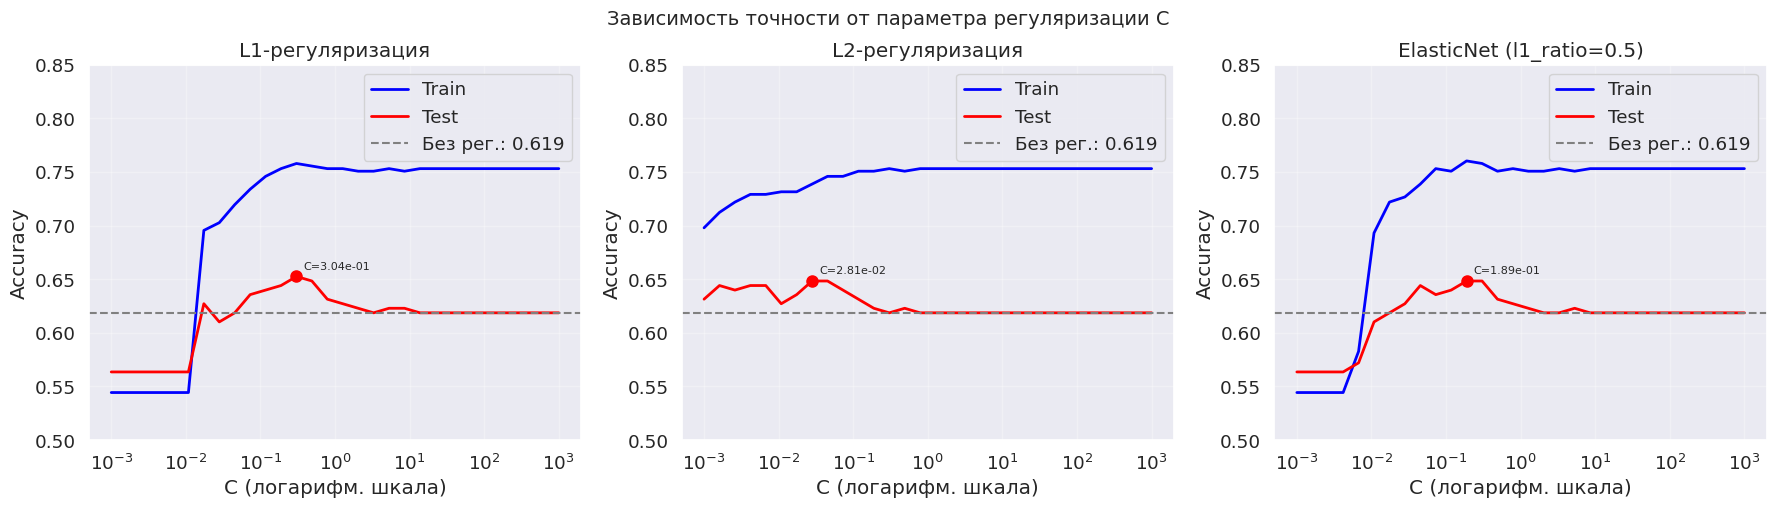

In [55]:
# Обучаем модель без регуляризации, если ещё не обучали
model_no_reg = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('estimator', LogisticRegression(penalty=None, max_iter=1000, random_state=42))
])
model_no_reg.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, model_no_reg.predict(X_test))
print(f"Точность модели без регуляризации на тесте: {baseline_accuracy:.3f}")

# Графики зависимости точности от C
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

penalty_names = {'l1': 'L1-регуляризация',
                 'l2': 'L2-регуляризация',
                 'elasticnet': 'ElasticNet (l1_ratio=0.5)'}

for idx, (penalty, res) in enumerate(results.items()):
    ax = axes[idx]

    # Графики accuracy
    ax.semilogx(res['C_grid'], res['acc_train'], 'b-', label='Train', linewidth=2)
    ax.semilogx(res['C_grid'], res['acc_test'], 'r-', label='Test', linewidth=2)

    # Линия baseline (модель без регуляризации)
    ax.axhline(y=baseline_accuracy, color='gray', linestyle='--',
               linewidth=1.5, label=f'Без рег.: {baseline_accuracy:.3f}')

    # Лучшая точка
    best_idx = np.argmax(res['acc_test'])
    best_C = res['C_grid'][best_idx]
    best_acc = res['acc_test'][best_idx]
    ax.plot(best_C, best_acc, 'ro', markersize=8)
    ax.annotate(f'C={best_C:.2e}', xy=(best_C, best_acc),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

    ax.set_xlabel('C (логарифм. шкала)')
    ax.set_ylabel('Accuracy')
    ax.set_title(penalty_names[penalty])
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 0.85)

plt.tight_layout()
plt.suptitle('Зависимость точности от параметра регуляризации C', y=1.02, fontsize=14)
plt.show()

Сделайте вывод. Есть ли польза от регуляризации с точки зрения метрики?

**Вывод:**
Регуляризация не улучшила точность модели — оптимальные значения C дают ту же тестовую точность (0.619), что и модель без регуляризации. Однако она полезна, так как устраняет переобучение и делает модель более устойчивой, сохраняя качество на том же уровне.

**3.** **Число обусловленности**

Исследуйте зависимость числа обусловленности от параметра `C` для $L_2$-регуляризации. Постройте соответствующий график.

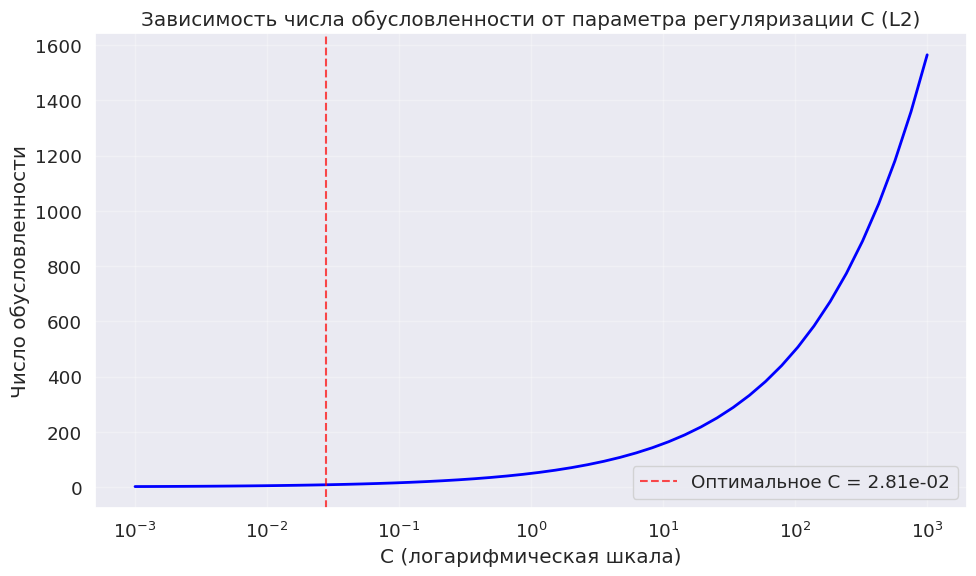

Число обусловленности без регуляризации: 2.83e+16
Число обусловленности при оптимальном C: 8.55e+00


In [56]:
# Получаем стандартизированные данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Исследуем зависимость числа обусловленности от C
C_grid = np.logspace(-3, 3, 50)
condition_numbers = []

for C in C_grid:
    # Для L2-регуляризации добавляем к матрице диагональ (1/C)
    # В логистической регрессии с L2-штрафом решение эквивалентно добавлению члена (1/C)*I
    lambda_reg = 1.0 / C
    X_reg = np.vstack([X_scaled, np.eye(X_scaled.shape[1]) * np.sqrt(lambda_reg)])
    condition_numbers.append(np.linalg.cond(X_reg))

# Построение графика
plt.figure(figsize=(10, 6))
plt.semilogx(C_grid, condition_numbers, 'b-', linewidth=2)
plt.xlabel('C (логарифмическая шкала)')
plt.ylabel('Число обусловленности')
plt.title('Зависимость числа обусловленности от параметра регуляризации C (L2)')
plt.grid(True, alpha=0.3)

# Отмечаем оптимальное C из предыдущих экспериментов
if 'l2' in results:
    best_idx = np.argmax(results['l2']['acc_test'])
    best_C = results['l2']['C_grid'][best_idx]
    plt.axvline(x=best_C, color='red', linestyle='--', alpha=0.7, label=f'Оптимальное C = {best_C:.2e}')
    plt.legend()

plt.tight_layout()
plt.show()

print(f"Число обусловленности без регуляризации: {np.linalg.cond(X_scaled):.2e}")
print(f"Число обусловленности при оптимальном C: {condition_numbers[np.argmin(np.abs(C_grid - best_C))]:.2e}")

Сделайте вывод. О чём свидетельствует полученная зависимость?

**Вывод:**

**4.** **Разброс коэффициентов**

Рассмотрите **2 модели:** логистическая регрессия с $L_2$-регуляризацией при `C=0.01` и с `penalty=None`. Каждую модель обучите 500 раз при различных разбиениях на обучающую и тестову выборки. Сохраните коэффициенты для выбранных ранее признаков. Подсчитайте усреднённую метрику качества и визуализируйте распределение каждого коэффициента. Не забудьте про пайплайн.

> Визуализацию предлагается сделать виде сетки графиков. На каждом изобразите **ядерные оценки плотности** ([`sns.kdeplot`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html)) для соответствующего коэффициента обеих моделей.
>
> Также напоминаем про удобство использования [логарифмической шкалы](https://matplotlib.org/stable/api/scale_api.html#builtin-scales).

In [60]:
# Параметры эксперимента
n_splits = 500
test_size = 0.4
random_state = 42

# Словари для хранения результатов
coefs_no_reg = {col: [] for col in X.columns}
coefs_l2 = {col: [] for col in X.columns}
acc_no_reg = []
acc_l2 = []
bal_acc_no_reg = []
bal_acc_l2 = []

# Создаем пайплайны для обеих моделей
pipeline_no_reg = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('estimator', LogisticRegression(penalty=None, max_iter=2000, random_state=42))
])

pipeline_l2 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('estimator', LogisticRegression(penalty='l2', C=0.01, max_iter=2000, random_state=42))
])

# Основной цикл по разбиениям
for i in tqdm(range(n_splits), desc="Обучение моделей"):
    # Создаем новое разбиение с сохранением групп
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state + i)
    train_idx, test_idx = next(gss.split(X, y, groups))

    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Модель без регуляризации
    pipeline_no_reg.fit(X_tr, y_tr)
    y_pred = pipeline_no_reg.predict(X_te)
    acc_no_reg.append(accuracy_score(y_te, y_pred))
    bal_acc_no_reg.append(balanced_accuracy_score(y_te, y_pred))

    # Сохраняем коэффициенты
    coef = pipeline_no_reg.named_steps['estimator'].coef_.flatten()
    for j, col in enumerate(X.columns):
        coefs_no_reg[col].append(coef[j])

    # Модель с L2-регуляризацией (C=0.01)
    pipeline_l2.fit(X_tr, y_tr)
    y_pred = pipeline_l2.predict(X_te)
    acc_l2.append(accuracy_score(y_te, y_pred))
    bal_acc_l2.append(balanced_accuracy_score(y_te, y_pred))

    # Сохраняем коэффициенты
    coef = pipeline_l2.named_steps['estimator'].coef_.flatten()
    for j, col in enumerate(X.columns):
        coefs_l2[col].append(coef[j])



print(f"\Модель без регуляризации:")
print(f"  Accuracy: {np.mean(acc_no_reg):.4f} ± {np.std(acc_no_reg):.4f}")
print(f"  Balanced accuracy: {np.mean(bal_acc_no_reg):.4f} ± {np.std(bal_acc_no_reg):.4f}")

print(f"\Модель с L2-регуляризацией (C=0.01):")
print(f"  Accuracy: {np.mean(acc_l2):.4f} ± {np.std(acc_l2):.4f}")
print(f"  Balanced accuracy: {np.mean(bal_acc_l2):.4f} ± {np.std(bal_acc_l2):.4f}")


Обучение моделей:   0%|          | 0/500 [00:00<?, ?it/s]

\Модель без регуляризации:
  Accuracy: 0.6414 ± 0.0457
  Balanced accuracy: 0.6375 ± 0.0423
\Модель с L2-регуляризацией (C=0.01):
  Accuracy: 0.6530 ± 0.0543
  Balanced accuracy: 0.6490 ± 0.0467


Визуализация

Обучение моделей:   0%|          | 0/500 [00:00<?, ?it/s]

УСРЕДНЕННЫЕ МЕТРИКИ (по 500 разбиениям)

Модель без регуляризации:
  Accuracy: 0.6414 ± 0.0457
  Balanced accuracy: 0.6375 ± 0.0423

Модель с L2-регуляризацией (C=0.01):
  Accuracy: 0.6530 ± 0.0543
  Balanced accuracy: 0.6490 ± 0.0467


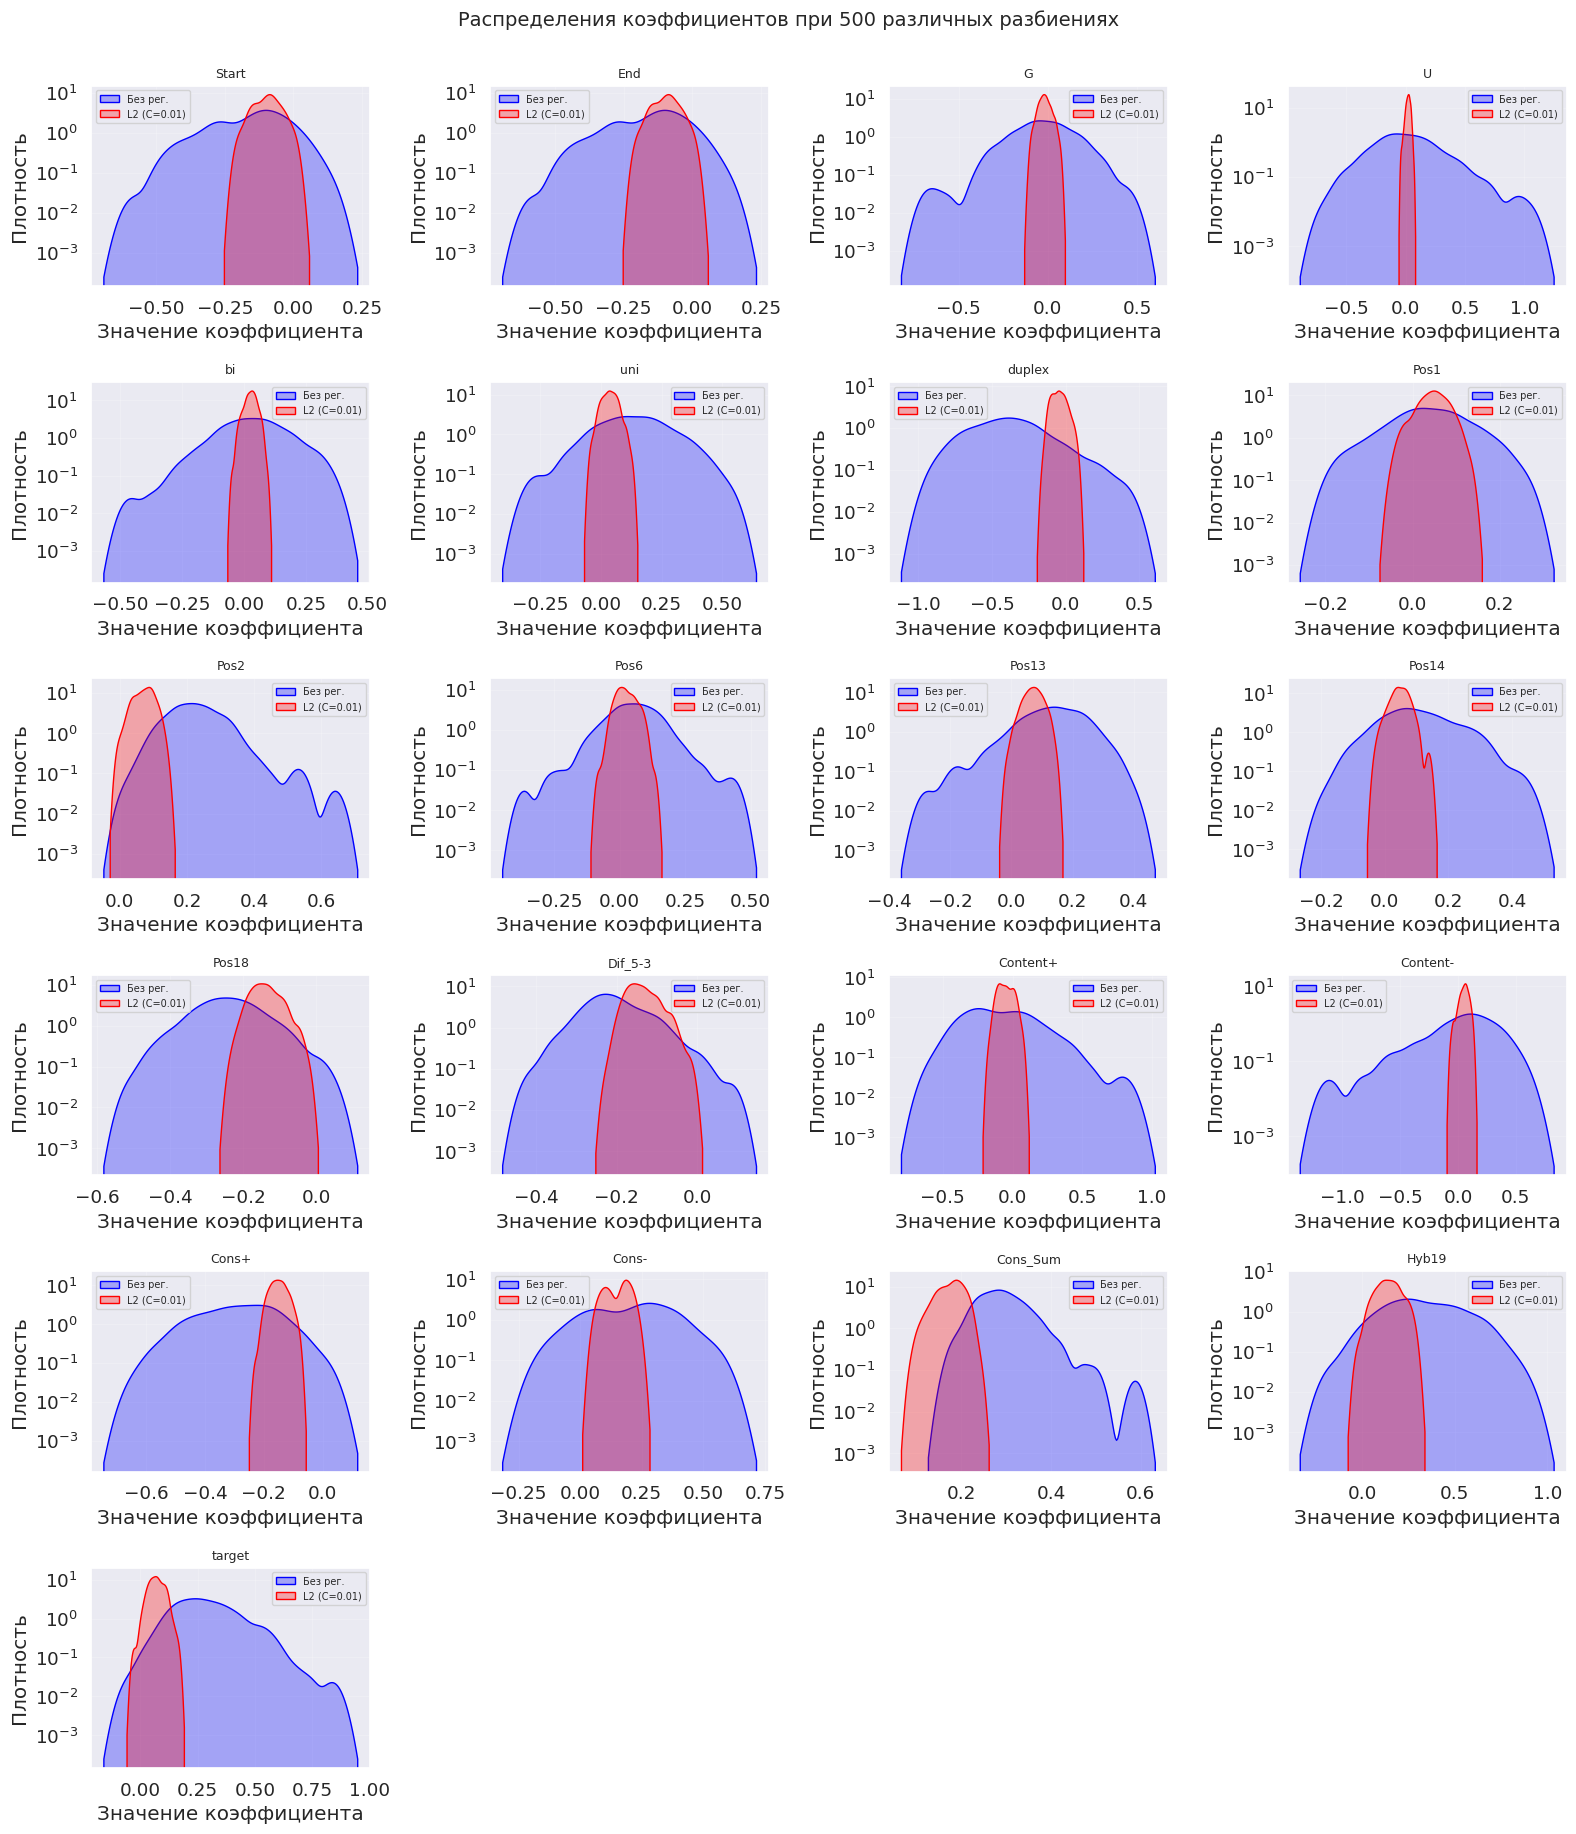

In [59]:
# Визуализация распределений коэффициентов
n_features = len(X.columns)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for idx, col in enumerate(X.columns):
    ax = axes[idx]

    # KDE для модели без регуляризации
    sns.kdeplot(coefs_no_reg[col], ax=ax, label='Без рег.', color='blue', fill=True, alpha=0.3)

    # KDE для модели с L2-регуляризацией
    sns.kdeplot(coefs_l2[col], ax=ax, label='L2 (C=0.01)', color='red', fill=True, alpha=0.3)

    ax.set_title(f'{col[:20]}...' if len(col) > 20 else col, fontsize=9)
    ax.set_xlabel('Значение коэффициента')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

    # Логарифмическая шкала для y
    ax.set_yscale('log')

# Скрываем пустые графики
for idx in range(len(X.columns), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.suptitle('Распределения коэффициентов при 500 различных разбиениях', y=1.02, fontsize=14)
plt.show()

Какой модели вы больше доверитесь при интерпретации коэффициентов? Почему разработчики sklearn по-умолчанию добавили в логистическую регрессию небольшую $L_2$-регуляризацию? В чём заключается её польза? Порассуждайте над этими вопросами и попробуйте написать интерпретацию выведенных коэффициентов.

**Вывод**

**Интересные статьи:**

[Червивый путь к Нобелю: история miRNA и больших открытий](https://nplus1.ru/material/2024/10/08/microrna-nobel2024)

---
### Задача 3.

Рассмотрим модель логистической регрессии. Признаки объекта представимы в виде $d$-мерного вектора $x \in \mathbb{R}^d$, класс имеет бернулиевское распределение $Y \sim Bern(\mu_\theta(x))$. Мы делаем следующее предположение о зависимости параметра вероятности от признаков:
$${\mu_\theta(x) = \sigma(x^T\theta)= \cfrac{1}{1 + e^{-x^T\theta}}}.$$

Зададим регуляризацию через минимизацию следующего функционала:

$$F(\theta) = -\sum_{i=1}^n \left[Y_i \log{\sigma(\theta^T x_i)} + (1 - Y_i) \log{\left(1 - \sigma(\theta^T x_i)\right)}\right] + \lambda\theta^T \theta.$$

**1.** Выведите формулы градиентного спуска (GD) и стохастического градиентного спуска (SGD).

<...>

**2.** Покажите, что $F(\theta)$ &mdash; выпуклая функция по $\theta$ и, как следствие, имеет единственный экстремум, являющийся глобальным максимумом. *Указание*. Посчитайте гессиан (матрицу вторых производных) и покажите, что она положительно определена.

<...>

**3.** Опишите, как может вести себя решение при отсутствии регуляризации, то есть при $\lambda = 0$

<...>

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для Phystech@DataScience